In [2]:
#Redirecting to Project Base

import os 
import sys
from pathlib import Path
BASE = Path.cwd().parent.parent.parent
sys.path.insert(0, str(BASE))

In [3]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

#Importing Classes
from src.data import Data

/Users/rohit/venv/time-series-venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data_handler = Data()

Loading data...
Data already exists
Data loaded succesfully!


In [5]:
product_id = 'HOBBIES_1_147_CA_1_validation'

In [6]:
df = data_handler.get_train_data(product_id, choice1 = 'train' , choice2 = 'single_prod_day_wise')

In [7]:
df.T

,142
d_210,0
d_211,0
d_212,0
d_213,0
d_214,0
...,...
d_1796,11
d_1797,4
d_1798,24
d_1799,5


In [8]:
sales = df.iloc[0].values

In [9]:
sales

array([ 0,  0,  0, ..., 24,  5, 13], shape=(1591,))

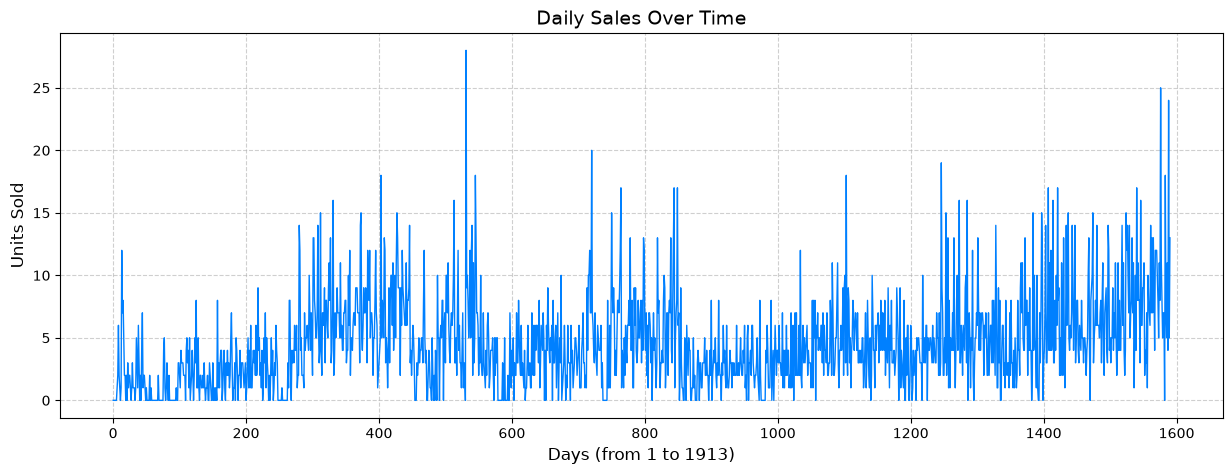

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(sales, color="#0080ff", linewidth=1)

plt.title("Daily Sales Over Time", fontsize=14)
plt.xlabel("Days (from 1 to 1913)", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [11]:
sales_series = pd.Series(sales)

In [12]:
sales_series

0        0
1        0
2        0
3        0
4        0
        ..
1586    11
1587     4
1588    24
1589     5
1590    13
Length: 1591, dtype: int64

In [13]:
sma_7 = sales_series.rolling(window=7).mean().round(2).astype("Float64")
sma_30 = sales_series.rolling(window=30).mean().round(2).astype("Float64")
sma_60 = sales_series.rolling(window=60).mean().round(2).astype("Float64")
sma_100 = sales_series.rolling(window=100).mean().round(2).astype("Float64")

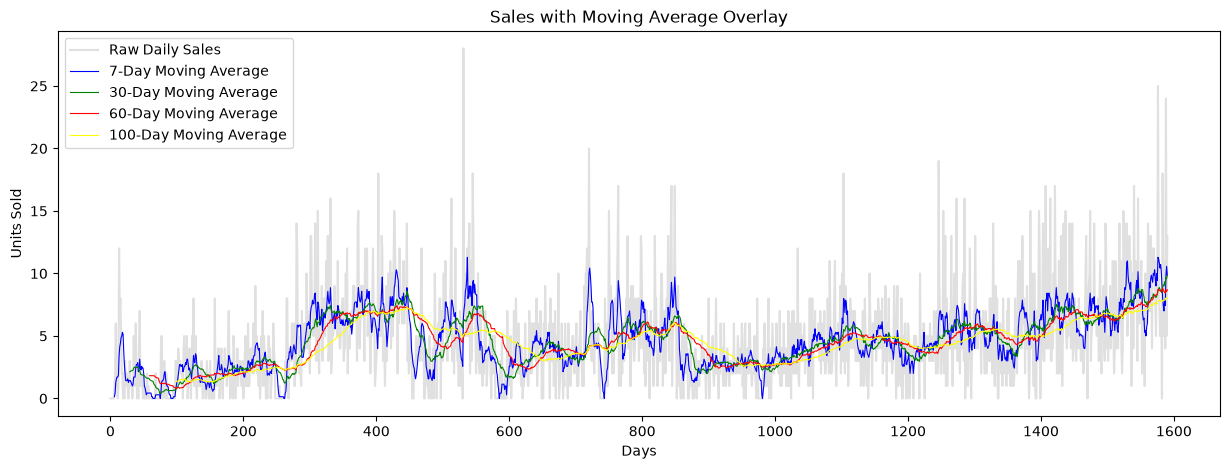

In [14]:
plt.figure(figsize=(15, 5))
plt.plot(sales_series, color='lightgrey', label='Raw Daily Sales', alpha=0.7)
plt.plot(sma_7, color='blue', label='7-Day Moving Average', linewidth=0.8)
plt.plot(sma_30, color='green', label='30-Day Moving Average', linewidth=0.8)
plt.plot(sma_60, color='red', label='60-Day Moving Average', linewidth=0.8)
plt.plot(sma_100, color='yellow', label='100-Day Moving Average', linewidth=0.8)


plt.title("Sales with Moving Average Overlay")
plt.xlabel("Days")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

In [14]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore") # Hides convergence warnings

# 1. Define the MA order (q). Let's use q=7 for a weekly error memory.
q = 7 

# 2. Fit the MA(q) model. (ARIMA with p=0, d=0, q=7)
model = ARIMA(sales_series, order=(0, 0, q))
ma_fit = model.fit()

# 3. Forecast the next 28 days
#forecast_28_days = ma_fit.forecast(steps=28).astype("int")
forecast_28_days = ma_fit.forecast(steps=130)

print("Forecast for the next 28 days:")
print(forecast_28_days)

Forecast for the next 28 days:
1591    7.896348
1592    6.790581
1593    7.578267
1594    7.369416
1595    6.616722
          ...   
1716    4.561660
1717    4.561660
1718    4.561660
1719    4.561660
1720    4.561660
Name: predicted_mean, Length: 130, dtype: float64


In [15]:
from src.models.classical.stationarity_test import check_stationarity, check_station

In [16]:
res = check_stationarity(sales_series , alpha = 0.05 , regression = "c")

In [17]:
print(f"ADF : stat={res['adf_stat']:.4f}  p={res['adf_p']:.4f}")
print(f"KPSS: stat={res['kpss_stat']:.4f}  p={res['kpss_p']:.4f}")
print("Verdict:", res["verdict"])

ADF : stat=-4.3915  p=0.0003
KPSS: stat=1.5665  p=0.0100
Verdict: difference-stationary conflict: likely trend-stationary -> detrend


In [1]:
result = check_station(sales_series)

NameError: name 'check_station' is not defined

In [36]:
print(result[0])

TypeError: 'NoneType' object is not subscriptable

In [38]:
prod_list = data_handler.get_prod_id_list()

In [39]:
prod_list

0        HOBBIES_1_001_CA_1_validation
1        HOBBIES_1_002_CA_1_validation
2        HOBBIES_1_003_CA_1_validation
3        HOBBIES_1_004_CA_1_validation
4        HOBBIES_1_005_CA_1_validation
                     ...              
30485      FOODS_3_823_WI_3_validation
30486      FOODS_3_824_WI_3_validation
30487      FOODS_3_825_WI_3_validation
30488      FOODS_3_826_WI_3_validation
30489      FOODS_3_827_WI_3_validation
Name: id, Length: 30490, dtype: str